# Hopfield's Artificial Neural Networks:

In [1]:
import modules.hopfield_network as hp
import matplotlib.pyplot as plt

## Network Training Pipeline:

### Random Memories (Stability Efficiency):

#### Defining the memories:

In [2]:
N = 25 # Number of neurons

P = 2  # Number of memories

random_memories = hp.patterns(N, P)

#### Applying Hebbian's Training Rule:

In [3]:
rand_weights = hp.train(N, random_memories)

#### Testing Network:

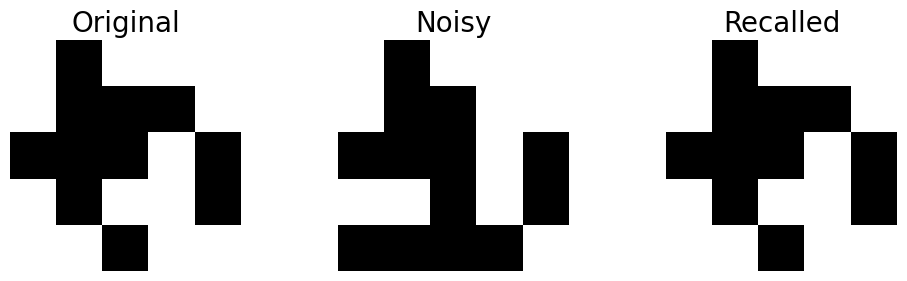

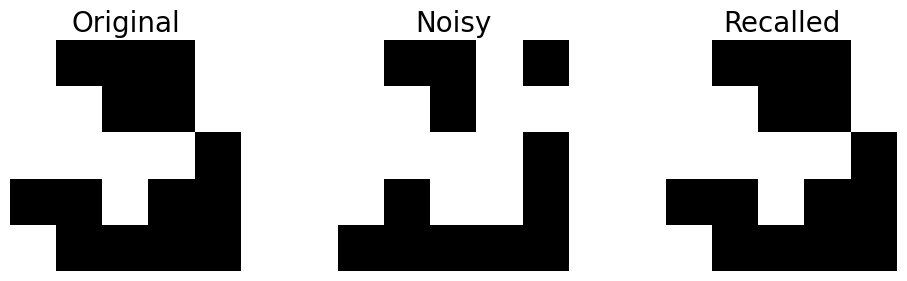

In [4]:
hp.test_network(random_memories, rand_weights, 0.25, label = "random_memory")

#### Visualizing our Artificial Intelligence's core:

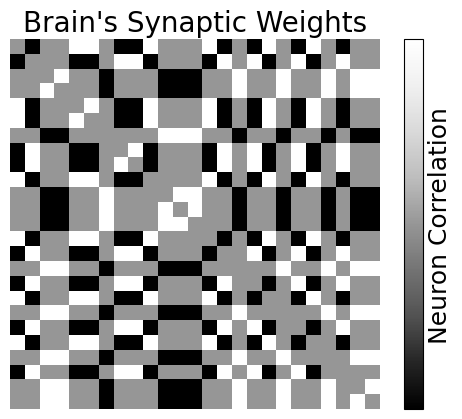

In [5]:
hp.see_synapses(rand_weights,figlabel = "rand_mem_synapses")

### Handpicked Memories (Visually Representative):

#### Pre-process Images:

In [6]:
img_ufsc, vetor_ufsc = hp.preprocessar_para_hopfield('dataset/ufsc.png', 
                                                     size=100, 
                                                     threshold=0.6, 
                                                     swap_colors=True)

In [7]:
img_github, vetor_github = hp.preprocessar_para_hopfield('dataset/github.png', 
                                                         size=100, threshold=0.60, 
                                                         swap_colors=True)

In [8]:
img_playstation, vetor_playstation = hp.preprocessar_para_hopfield('dataset/playstation.png', 
                                                                   size=100, 
                                                                   threshold=0.3, 
                                                                   swap_colors=False)

In [9]:
memories = [vetor_ufsc, vetor_github, vetor_playstation]

#### Train:

In [10]:
img_weights = hp.train(len(vetor_ufsc), memories)

#### Test:

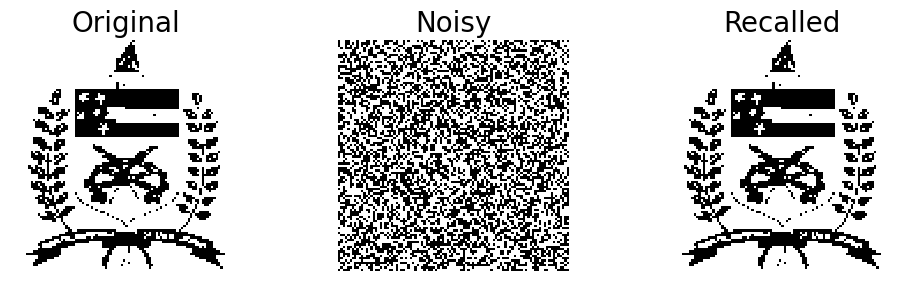

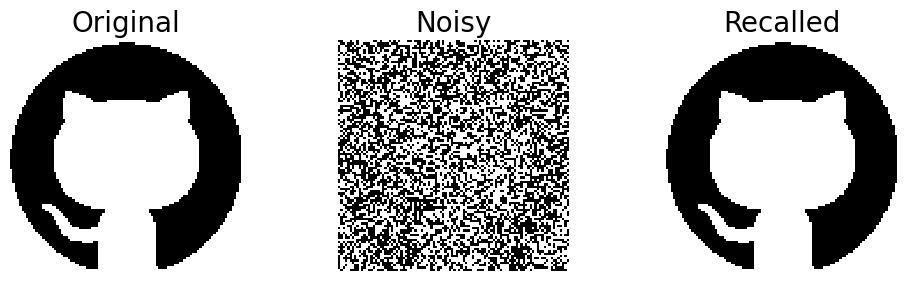

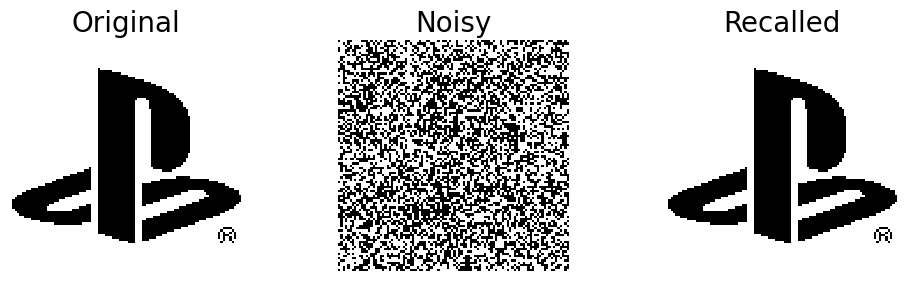

In [11]:
hp.test_network(memories, img_weights, noise_level=0.45, label = "image_memory")

#### Brain:

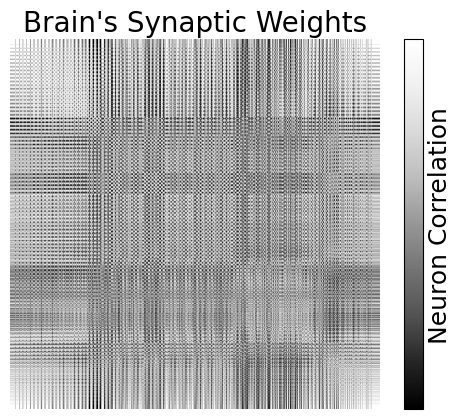

In [12]:
hp.see_synapses(img_weights,figlabel = "image_mem_synapses")

## Error Correction:

### Train with Original:

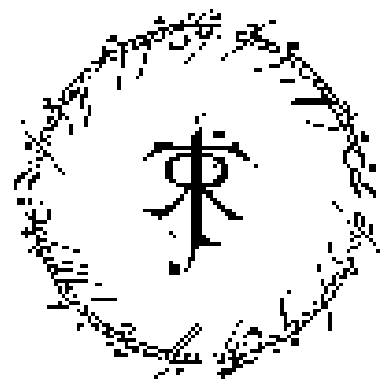

In [13]:
img_tolkien, vetor_tolkien = hp.preprocessar_para_hopfield("dataset/tolkien.png", 
                                                           size = 100, 
                                                           threshold = 0.90,
                                                           swap_colors = True)

img_weights = img_weights + hp.train(len(vetor_tolkien), [vetor_tolkien])

hp.vizualize([vetor_tolkien],[],[], len(vetor_tolkien), save = False, recall = False)

### Simulate Error:

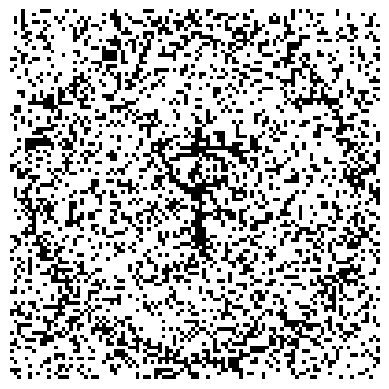

In [14]:
tolkien_wrong = hp.add_noise(vetor_tolkien, noise_level=0.25)

hp.vizualize([tolkien_wrong],[],[], len(tolkien_wrong), save = False, recall = False)

### Retrieve Converged Memory:

In [15]:
tolkien_corrected = hp.retrieve(len(vetor_tolkien), img_weights, tolkien_wrong)

Note that, to correct a pattern, we do not need the original, beyond the training phase, which makes perfect sense.

### Visualize Corrected:

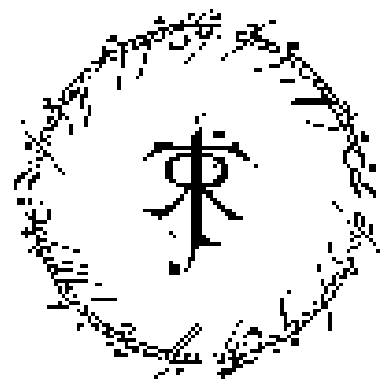

In [16]:
hp.vizualize([tolkien_corrected],[],[], len(tolkien_corrected), save = False, recall = False)

## Pattern Completion:

### Get Incomplete Pattern/Memory:

In [17]:
img_euler, vetor_euler = hp.preprocessar_para_hopfield("dataset/euler.png",
                                                       size = 100,
                                                       threshold = 0.2,
                                                       swap_colors = False)

img_weights = img_weights + hp.train(len(vetor_euler), [vetor_euler])

In [18]:
euler_incomplete = vetor_euler.copy()
euler_incomplete[8000:] = hp.add_noise(euler_incomplete[8000:], noise_level=0.50)

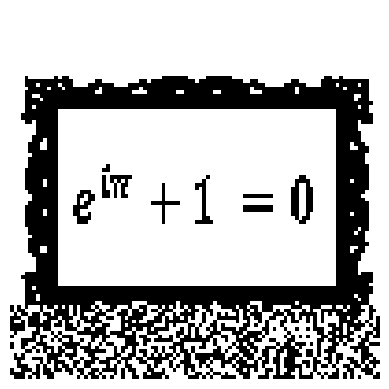

In [19]:
hp.vizualize([euler_incomplete],[],[], len(euler_incomplete), save = False, recall = False)

### Retrieve Converged Memory:

In [20]:
euler_completed = hp.retrieve_async(len(euler_incomplete), img_weights, euler_incomplete)

### Visualize Completed:

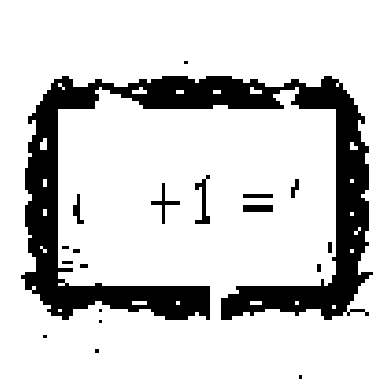

In [21]:
hp.vizualize([euler_completed],[],[], len(euler_completed), save = False, recall = False)

## Energy and Stability:

## Statistics and Hallucination Band: